# Notebook 05

# Extração de Características utilizando CKSAAGP

Nos notebooks anteriores foram implementados três descritores clássicos para representação de sequências peptídicas.

O descritor AAC representa apenas a composição global dos aminoácidos.

O descritor AAL incorpora a ordem local da sequência por meio de pares consecutivos.

O descritor CKSNAP amplia essa representação considerando pares separados por diferentes distâncias.

Entretanto, todos esses métodos apresentam uma característica em comum: cada aminoácido é tratado individualmente.

Do ponto de vista biológico, aminoácidos pertencentes ao mesmo grupo físico-químico frequentemente apresentam comportamentos semelhantes durante processos de interação molecular.

Para explorar essa informação será implementado neste notebook o descritor CKSAAGP (Composition of k-Spaced Amino Acid Group Pairs), que representa pares de grupos bioquímicos em diferentes distâncias ao longo da sequência.

## Objetivos

Ao final deste notebook será possível:

- compreender o descritor CKSAAGP;

- agrupar aminoácidos segundo propriedades físico-químicas;

- implementar o algoritmo do zero;

- construir a representação baseada em grupos;

- comparar o desempenho representacional com AAC, AAL e CKSNAP.

## Por que agrupar aminoácidos?

Considere os aminoácidos

```
I

L

V
```

Eles são diferentes. Entretanto,todos pertencem ao grupo dos aminoácidos hidrofóbicos. Do ponto de vista químico, podem desempenhar papéis semelhantes em diversas proteínas.

Assim, em vez de trabalhar com

```
20 aminoácidos
```

passaremos a trabalhar com

```
5 grupos bioquímicos.
```

Essa abordagem reduz significativamente a dimensionalidade mantendo parte da informação estrutural.

## Composition of k-Spaced Amino Acid Group Pairs

O descritor CKSAAGP substitui cada aminoácido pelo grupo físico-químico ao qual pertence. Em seguida, calcula a frequência dos pares de grupos separados por diferentes distâncias. Como existem apenas cinco grupos, existem

```
5 × 5 = 25
```

pares possíveis para cada valor de k.

Utilizando

```
k = 0,1,2,3,4,5
```

obtém-se

```
25 × 6 =150
```

atributos.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [45]:
df = pd.read_csv("../data/raw/sagapep.csv")
df.head(10)

,peptide_fasta_sequence,best_docking_score
0,RFGYGYGPY,-230.308
1,PAAAPPTLPPYFMKGSIIQLANGELKKV,-227.293
2,SIPPCPQTWRSLWIGYSFLMHTG,-224.630
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227
5,WAFTPLHEAAQKGRTQLCALLL,-214.970
6,PGPSSPYIPSPGGAMSPSYSPTSPAYEP,-210.899
7,SRGPPPRATRLPPPGPLCSSFSTP,-210.009
8,GRFGYGYGPY,-209.840
9,PRGPAGPSGPAGKDGRTGHPGTVGPAGIRGPQGHQGPAGPPGPPGP,-209.592


## Classificação dos aminoácidos

Neste trabalho foi utilizada a classificação proposta originalmente pelo descritor CKSAAGP. Cada aminoácido pertence exatamente a um grupo bioquímico.

In [46]:
grupos = {
    "g1":["G","A","V","L","I","P"],
    "g2":["F","Y","W"],
    "g3":["K","R","H"],
    "g4":["D","E"],
    "g5":["S","T","C","M","N","Q"]
}

In [47]:
grupo_df = []
for g,aas in grupos.items():
    for aa in aas:
        grupo_df.append(
            [aa,g]
        )

grupo_df = pd.DataFrame(
    grupo_df,
    columns=[
        "Aminoácido",
        "Grupo"
    ]
)

grupo_df.sort_values(
    "Grupo"
)

,Aminoácido,Grupo
0,G,g1
1,A,g1
2,V,g1
3,L,g1
4,I,g1
5,P,g1
6,F,g2
7,Y,g2
8,W,g2
11,H,g3


Considere uma sequência contendo N aminoácidos. Após substituir cada aminoácido pelo seu grupo, contabilizam-se os pares separados por distância k.

A frequência relativa é definida por

\[
CKSAAGP_{ij}^{(k)}
=
\frac{n_{ij}^{(k)}}
{N-k-1}
\]

onde

\(i\) e \(j\)

representam grupos bioquímicos.

In [48]:
# Construindo o dicionário
aa_to_group = {}

for g,aas in grupos.items():
    for aa in aas:
        aa_to_group[aa]=g

In [49]:
# Criando os 25 pares
from itertools import product

group_pairs = [
    a+b
    for a,b in product(
        grupos.keys(),
        grupos.keys()
    )
]

group_pairs

['g1g1',
 'g1g2',
 'g1g3',
 'g1g4',
 'g1g5',
 'g2g1',
 'g2g2',
 'g2g3',
 'g2g4',
 'g2g5',
 'g3g1',
 'g3g2',
 'g3g3',
 'g3g4',
 'g3g5',
 'g4g1',
 'g4g2',
 'g4g3',
 'g4g4',
 'g4g5',
 'g5g1',
 'g5g2',
 'g5g3',
 'g5g4',
 'g5g5']

In [50]:
# Implementação
from collections import Counter

def cksaagp(sequence,k):
    seq = [
        aa_to_group[a]
        for a in sequence
    ]

    links = []

    for i in range(
        len(seq)-k-1
    ):

        links.append(
            seq[i]
            +
            seq[i+k+1]
        )

    total=len(links)
    counts=Counter(links)

    vector={}

    for p in group_pairs:
        if total==0:
            vector[p]=0

        else:
            vector[p]=counts.get(p,0)/total

    return vector

In [51]:
# Validação
cksaagp("AGPLKT",0)

{'g1g1': 0.6,
 'g1g2': 0.0,
 'g1g3': 0.2,
 'g1g4': 0.0,
 'g1g5': 0.0,
 'g2g1': 0.0,
 'g2g2': 0.0,
 'g2g3': 0.0,
 'g2g4': 0.0,
 'g2g5': 0.0,
 'g3g1': 0.0,
 'g3g2': 0.0,
 'g3g3': 0.0,
 'g3g4': 0.0,
 'g3g5': 0.2,
 'g4g1': 0.0,
 'g4g2': 0.0,
 'g4g3': 0.0,
 'g4g4': 0.0,
 'g4g5': 0.0,
 'g5g1': 0.0,
 'g5g2': 0.0,
 'g5g3': 0.0,
 'g5g4': 0.0,
 'g5g5': 0.0}

In [52]:
sum(cksaagp("AGPLKT",2).values())

1.0

In [53]:
# Construindo a matriz
dfs=[]

for k in range(6):
    temp=(
        df["peptide_fasta_sequence"]
        .apply(
            lambda x:
            cksaagp(
                x,
                k
            )
        )
        .apply(pd.Series)
    )

    temp.columns=[
        f"{c}_k{k}"
        for c in temp.columns
    ]
    dfs.append(temp)

In [54]:
cksaagp_df = pd.concat(
    dfs,
    axis=1
)

cksaagp_df[
    "best_docking_score"
]=df[
    "best_docking_score"
]

cksaagp_df

,g1g1_k0,g1g2_k0,g1g3_k0,g1g4_k0,g1g5_k0,g2g1_k0,g2g2_k0,g2g3_k0,g2g4_k0,g2g5_k0,...,g4g2_k5,g4g3_k5,g4g4_k5,g4g5_k5,g5g1_k5,g5g2_k5,g5g3_k5,g5g4_k5,g5g5_k5,best_docking_score
0,0.125000,0.375000,0.000000,0.000000,0.000000,0.375000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-230.308
1,0.333333,0.037037,0.037037,0.037037,0.148148,0.000000,0.037037,0.000000,0.0,0.037037,...,0.0,0.0,0.0,0.0,0.090909,0.000000,0.000000,0.000000,0.136364,-227.293
2,0.136364,0.090909,0.000000,0.000000,0.136364,0.090909,0.000000,0.045455,0.0,0.045455,...,0.0,0.0,0.0,0.0,0.117647,0.058824,0.000000,0.000000,0.176471,-224.630
3,0.181818,0.272727,0.090909,0.000000,0.000000,0.272727,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-218.979
4,0.200000,0.100000,0.100000,0.000000,0.100000,0.000000,0.000000,0.100000,0.0,0.100000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-218.227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,0.187500,0.000000,0.062500,0.062500,0.125000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.272727,0.000000,0.090909,0.000000,0.000000,-149.184
292,0.200000,0.000000,0.100000,0.000000,0.200000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.200000,0.000000,0.000000,0.000000,0.000000,-167.486
293,0.909091,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.166667,0.000000,0.000000,0.000000,0.000000,-169.224
294,0.105263,0.000000,0.052632,0.105263,0.157895,0.000000,0.000000,0.000000,0.0,0.052632,...,0.0,0.0,0.0,0.0,0.142857,0.000000,0.000000,0.142857,0.071429,-160.745


## Validação da matriz CKSAAGP

Assim como nos descritores anteriores, a implementação do CKSAAGP deve preservar a propriedade de normalização das frequências. Para cada valor de \(k\), a soma das frequências dos 25 pares de grupos bioquímicos deve ser igual a 1 para todas as sequências.

In [55]:
# ============================================================
# Validação da matriz CKSAAGP
# ============================================================

for k in range(6):
    cols = [
        c for c in cksaagp_df.columns
        if c.endswith(f"_k{k}")
    ]

    soma = cksaagp_df[cols].sum(axis=1)
    print(f"k={k}")
    print(f"mínimo = {soma.min():.6f}")
    print(f"máximo = {soma.max():.6f}")
    assert np.allclose(soma,1)
print("\n✓ Validação concluída.")

k=0
mínimo = 1.000000
máximo = 1.000000
k=1
mínimo = 1.000000
máximo = 1.000000
k=2
mínimo = 1.000000
máximo = 1.000000
k=3
mínimo = 1.000000
máximo = 1.000000
k=4
mínimo = 1.000000
máximo = 1.000000
k=5
mínimo = 1.000000
máximo = 1.000000

✓ Validação concluída.


In [56]:
# Estatística Descritiva
estatisticas = (
    cksaagp_df
    .drop(columns="best_docking_score")
    .describe()
    .T
)

estatisticas["variance"] = (
    cksaagp_df
    .drop(columns="best_docking_score")
    .var()
)

estatisticas.sort_values(

    "variance",

    ascending=False

).head(20)

,count,mean,std,min,25%,50%,75%,max,variance
g1g1_k5,296.0,0.295658,0.232445,0.0,0.131250,0.258333,0.454545,1.000000,0.054031
g1g1_k2,296.0,0.311327,0.230460,0.0,0.125000,0.267943,0.480000,0.900000,0.053112
g1g1_k0,296.0,0.301438,0.226887,0.0,0.111111,0.254630,0.446970,0.909091,0.051478
g1g1_k4,296.0,0.302509,0.223774,0.0,0.142857,0.263158,0.448026,1.000000,0.050075
g1g1_k1,296.0,0.311335,0.222234,0.0,0.133333,0.275253,0.449843,0.900000,0.049388
g1g1_k3,296.0,0.311888,0.214402,0.0,0.156883,0.264912,0.444444,0.896552,0.045968
g5g1_k5,296.0,0.112727,0.141007,0.0,0.000000,0.077037,0.176471,1.000000,0.019883
g1g5_k5,296.0,0.130167,0.140347,0.0,0.000000,0.111111,0.217391,0.666667,0.019697
g5g1_k4,296.0,0.101963,0.117111,0.0,0.000000,0.086957,0.166667,0.666667,0.013715
g1g5_k4,296.0,0.120884,0.114593,0.0,0.000000,0.125000,0.200000,0.571429,0.013132


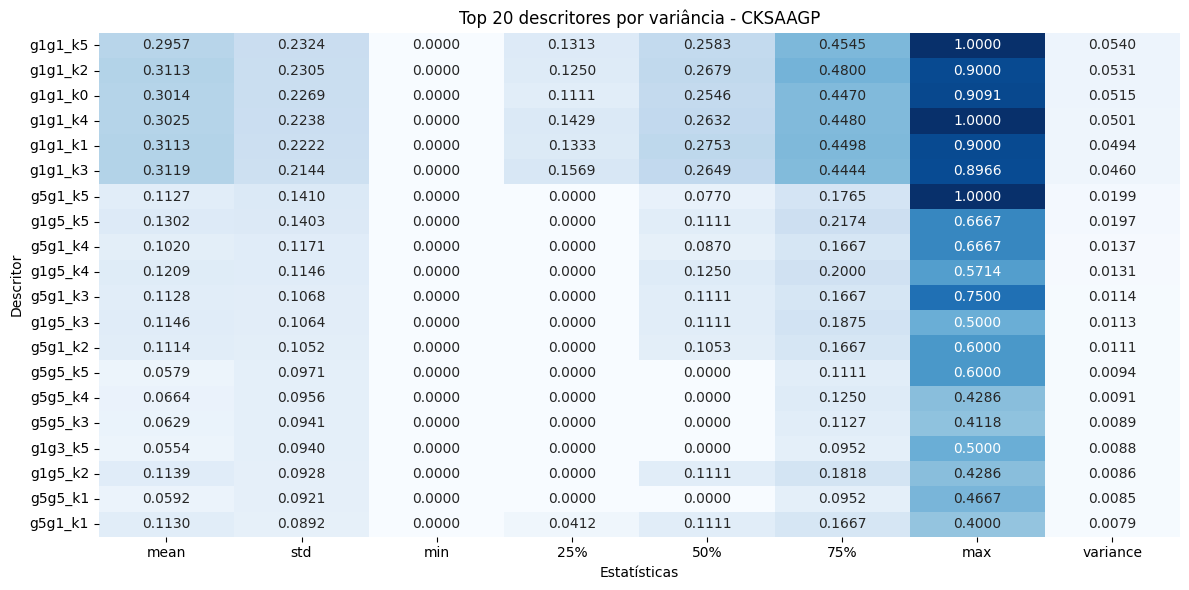

In [70]:
top20_stats = (
    estatisticas
    .drop(columns=["count"])
    .sort_values("variance", ascending=False)
    .head(20)
)

# ============================================================
# Plotando como tabela
# ============================================================
plt.figure(figsize=(12,6))
sns.heatmap(
    top20_stats,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    cbar=False
)
plt.title("Top 20 descritores por variância - CKSAAGP")
plt.xlabel("Estatísticas")
plt.ylabel("Descritor")
plt.tight_layout()
plt.show()

In [57]:
media = (
    cksaagp_df
    .drop(columns="best_docking_score")
    .mean()
    .sort_values(
        ascending=False
    )
)

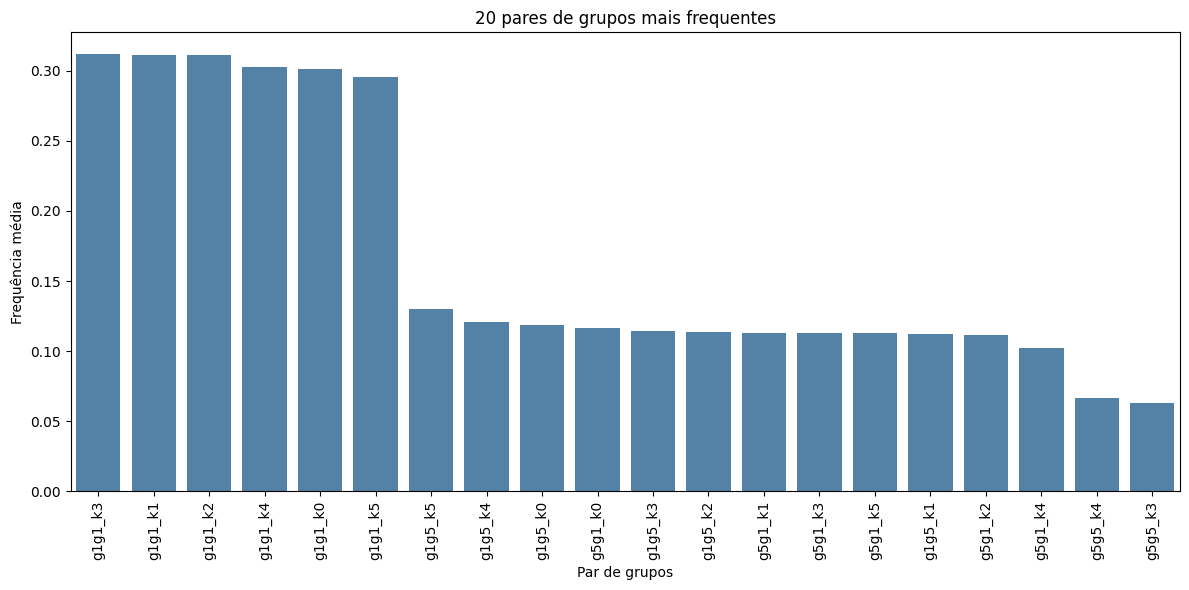

In [58]:
top20 = media.head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top20.index,
    y=top20.values,
    color="steelblue"
)

plt.xticks(rotation=90)

plt.title(
    "20 pares de grupos mais frequentes"
)

plt.xlabel("Par de grupos")
plt.ylabel("Frequência média")
plt.tight_layout()
plt.show()

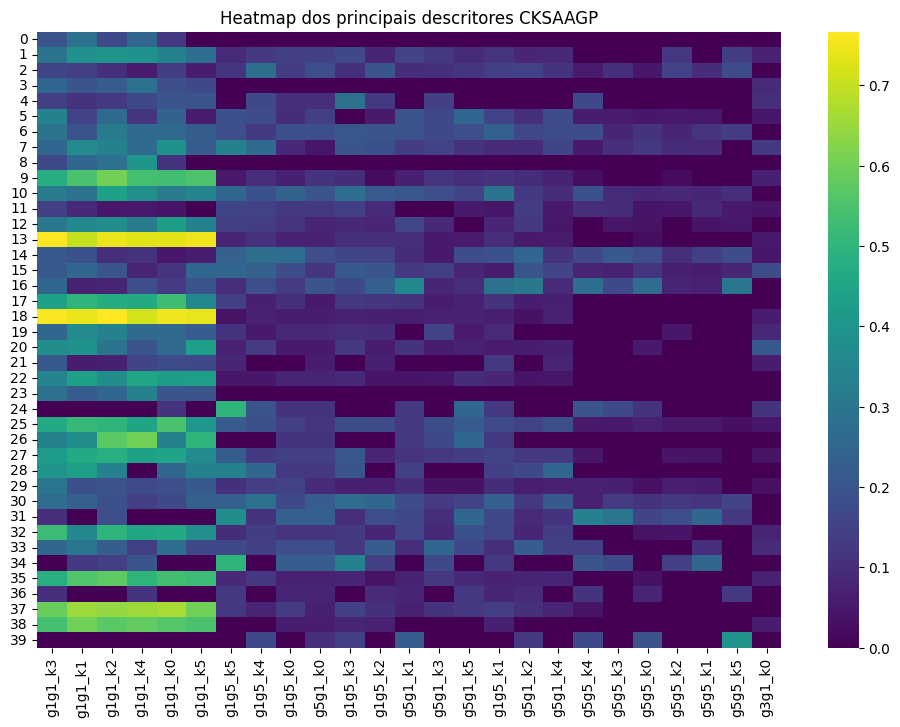

In [59]:
# Heatmap
top25 = media.head(25).index

plt.figure(figsize=(12,8))
sns.heatmap(
    cksaagp_df[
        top25
    ].iloc[:40],
    cmap="viridis"
)

plt.title(
    "Heatmap dos principais descritores CKSAAGP"
)

plt.show()

In [60]:
# Correlação
corr_target = (
    cksaagp_df
    .corr(numeric_only=True)[
        "best_docking_score"
    ]
    .drop(
        "best_docking_score"
    )
)

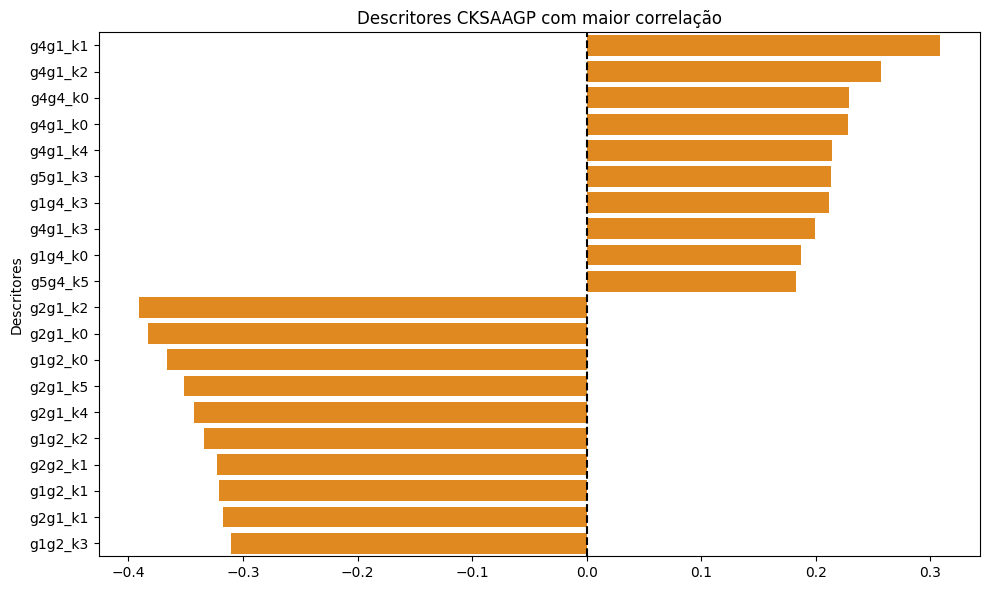

In [71]:
top = pd.concat([
    corr_target.nlargest(10),
    corr_target.nsmallest(10)
])

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index,
    color="darkorange"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Descritores CKSAAGP com maior correlação"
)

plt.tight_layout()
plt.ylabel("Descritores")
plt.show()

In [62]:
# Informação Mútua
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    cksaagp_df.drop(
        columns="best_docking_score"
    ),
    cksaagp_df[
        "best_docking_score"
    ],
    random_state=42
)

mi = pd.Series(
    mi,
    index=
    cksaagp_df.drop(
        columns="best_docking_score"
    ).columns
).sort_values(
    ascending=False
)

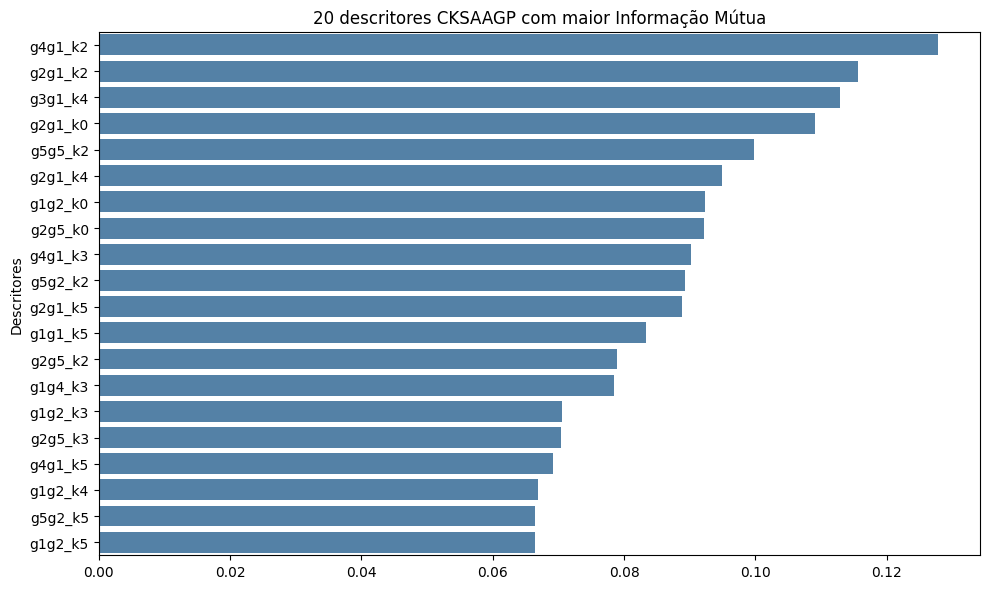

In [74]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=mi.head(20).values,
    y=mi.head(20).index,
    color="steelblue"
)
plt.title(
    "20 descritores CKSAAGP com maior Informação Mútua"
)
plt.tight_layout()
plt.ylabel("Descritores")
plt.show()

In [64]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(
    cksaagp_df.drop(
        columns="best_docking_score"
    )
)

pca_cksaagp = PCA(
    n_components=2
)

X_pca = pca_cksaagp.fit_transform(X)

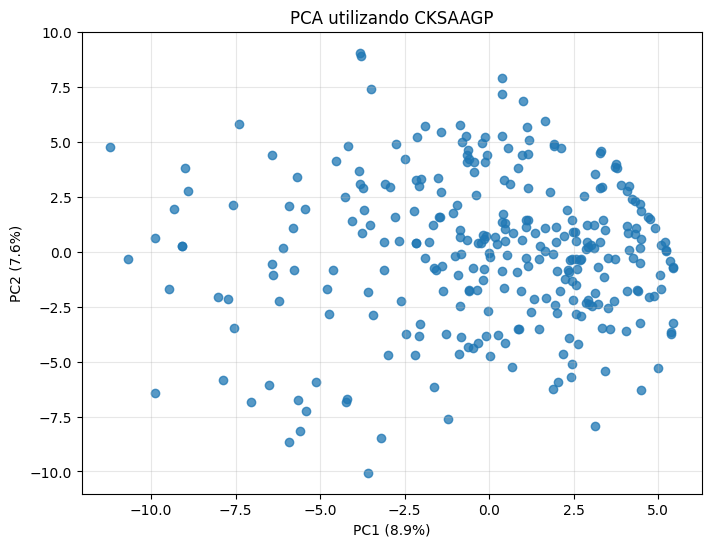

In [65]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.75
)

plt.title(
    "PCA utilizando CKSAAGP"
)

plt.xlabel(
    f"PC1 ({100*pca_cksaagp.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca_cksaagp.explained_variance_ratio_[1]:.1f}%)"
)

plt.grid(alpha=0.3)

plt.show()

In [66]:
# Salvar o objeto PCA
import pickle

with open("../data/processed/pca_cksaagp.pkl", "wb") as f:
    pickle.dump(pca_cksaagp, f)

In [67]:
# Comparação AAC × AAL × CKSNAP × CKSAAGP

with open("../data/processed/pca_aac.pkl", "rb") as f:
    pca_aac = pickle.load(f)

with open("../data/processed/pca_aal.pkl", "rb") as f:
    pca_aal = pickle.load(f)

with open("../data/processed/pca_cksnap.pkl", "rb") as f:
    pca_cksnap = pickle.load(f)


aac_df = pd.read_csv("../data/processed/aac_features.csv")
aac_only = aac_df.drop(columns=["best_docking_score"])

aal_df = pd.read_csv("../data/processed/aal_features.csv")
aal_only = aal_df.drop(columns=["best_docking_score"])

cksnap_df = pd.read_csv("../data/processed/cksnap_features.csv")
cksnap_only = cksnap_df.drop(columns=["best_docking_score"])


comparacao = pd.DataFrame({
    "AAC":[
        aac_only.shape[1],
        aac_only.var().mean(),
        pca_aac.explained_variance_ratio_.sum()
    ],

    "AAL":[
        aal_only.shape[1],
        aal_only.var().mean(),
        pca_aal.explained_variance_ratio_.sum()
    ],

    "CKSNAP":[
        cksnap_df.drop(
            columns="best_docking_score"
        ).shape[1],
        cksnap_df.drop(
            columns="best_docking_score"
        ).var().mean(),
        pca_cksnap.explained_variance_ratio_.sum()
    ],

    "CKSAAGP":[
        cksaagp_df.drop(
            columns="best_docking_score"
        ).shape[1],
        cksaagp_df.drop(
            columns="best_docking_score"
        ).var().mean(),
        pca_cksaagp.explained_variance_ratio_.sum()
    ]
},

index=[
    "Número de atributos",
    "Variância média",
    "Variância explicada (PCA)"
])

comparacao

,AAC,AAL,CKSNAP,CKSAAGP
Número de atributos,20.000000,400.000000,2400.000000,150.000000
Variância média,0.005424,0.000270,0.000332,0.005117
Variância explicada (PCA),0.191438,0.027737,0.022264,0.165072


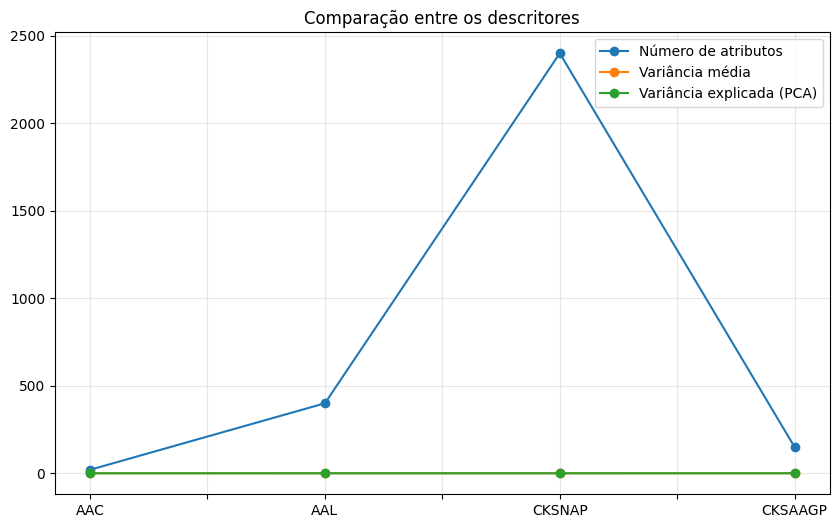

In [68]:
comparacao.T.plot(
    figsize=(10,6),
    marker="o"
)

plt.title(
    "Comparação entre os descritores"
)

plt.grid(alpha=0.3)
plt.show()

In [69]:
# Salvando
cksaagp_df.to_csv(
    "../data/processed/cksaagp_features.csv",
    index=False
)
print(
    "Dataset CKSAAGP salvo."
)

Dataset CKSAAGP salvo.


## Conclusões

Neste notebook foi implementado o descritor **Composition of k-Spaced Amino Acid Group Pairs (CKSAAGP)**, que representa as sequências peptídicas por meio de pares de grupos bioquímicos separados por diferentes distâncias.

Ao substituir aminoácidos individuais por grupos físico-químicos, o CKSAAGP reduz significativamente a dimensionalidade em relação ao CKSNAP, preservando simultaneamente informações estruturais relevantes.

As análises estatísticas demonstraram que essa representação apresenta boa variabilidade, reduzida esparsidade e maior interpretabilidade biológica, características desejáveis para problemas de Aprendizado de Máquina envolvendo conjuntos de dados de pequena dimensão.

Com a implementação do CKSAAGP conclui-se a etapa de engenharia de atributos deste trabalho. Os quatro descritores desenvolvidos (AAC, AAL, CKSNAP e CKSAAGP) serão utilizados no próximo notebook para treinamento, comparação e avaliação dos modelos de regressão empregados na predição da energia de docking dos peptídeos da base SAGAPEP.